# **Transformer Embeddings, Topic Modeling, and Soft Clustering**

## **Set-Up**

In [168]:
# Base Python libraries
import pandas as pd
import numpy as np
import re
import os

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Stopwords for text preprocessing
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords

# NLP and topic modeling libraries
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# Supporting libraries
import torch
import gc
import time

### **Load Data & Clean**

In [169]:
raw_data = pd.read_csv("data/UWSM_Community_Input_Transcripts_Split.csv")

print("--"*50)
print("Raw Data Shape:")
print(raw_data.shape)
print("--"*50)

----------------------------------------------------------------------------------------------------
Raw Data Shape:
(1769, 11)
----------------------------------------------------------------------------------------------------


In [170]:
# Cleanup to cleaning the conversations: removing extra spaces, newlines, and tabs
def clean_text(text):

    # Remove special characters and numbers, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'[\n\r\t]+', ' ', text)
    text = re.sub(r'\b(Speaker)\s+(\d+)\b', r'\1\2', text)

    # Convert to lowercase
    text = text.lower()
    return text

In [171]:
# Apllying clean text function
raw_data["clean_text"] = raw_data["Text"].apply(clean_text)

In [172]:
# Capturing text length for each transcript
def text_length(text):
    return text.str.len()

In [173]:
raw_data["text_length"] = text_length(raw_data["clean_text"])

print("--"*50)
print("Transcript Length Statistics:")
print(raw_data["text_length"].describe())
print("--"*50)

----------------------------------------------------------------------------------------------------
Transcript Length Statistics:
count     1769.000000
mean       421.031656
std       1507.496238
min          6.000000
25%        129.000000
50%        251.000000
75%        480.000000
max      45027.000000
Name: text_length, dtype: float64
----------------------------------------------------------------------------------------------------


In [174]:
print("--"*50)
print("Cleaned Data:")
print("--"*50)
raw_data

----------------------------------------------------------------------------------------------------
Cleaned Data:
----------------------------------------------------------------------------------------------------


,Source File,Name of Facilitator(s),Date of Conversation,Name of Organization/Group,Meeting Location,Length of Time,Number of Attendees,Population,Summary Keywords,Speaker,Text,clean_text,text_length
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 1,"This is Pamela, and it's March 17, and I am at...",this is pamela and its march 17 and i am at av...,372
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 2,School System. The school system is specific t...,school system the school system is specific to...,313
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 3,I think the police department and fire departm...,i think the police department and fire departm...,455
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 1,Any other strengths have to be specific to Old...,any other strengths have to be specific to old...,104
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 1,friendship that we all have. We care for each ...,friendship that we all have we care for each o...,258
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1764,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 6,like friendship reasons. Can be a friendship r...,like friendship reasons can be a friendship ra...,129
1765,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 1,So I'm just gonna read some of the ones we hav...,so im just gonna read some of the ones we have...,527
1766,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 1,"by fast, I know well. Thank you all so so much...",by fast i know well thank you all so so much f...,216
1767,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 4,learn more about your organizations? Do you ha...,learn more about your organizations do you hav...,100


In [188]:
raw_data.isna().sum()

Source File                     0
Name of Facilitator(s)        103
Date of Conversation           93
Name of Organization/Group      0
Meeting Location              314
Length of Time                135
Number of Attendees             0
Population                      0
Summary Keywords              441
Speaker                         0
Text                            0
clean_text                      0
text_length                     0
dtype: int64

In [189]:
raw_data.select_dtypes(include = ["number"]).describe()

,text_length
count,1769.000000
mean,421.031656
std,1507.496238
min,6.000000
25%,129.000000
50%,251.000000
75%,480.000000
max,45027.000000


In [175]:
text_tokens = raw_data["clean_text"].str.split().to_list()
docs = raw_data["clean_text"].tolist()

## **Sentence Transformer**

In [176]:
# BGE M3 Implementation Code
bge_large = SentenceTransformer('BAAI/bge-large-en-v1.5')

print("--"*50)
print("BGE Large Model Loaded Successfully !!")
print("--"*50)
print("Model Details:")
print(f"Model loaded: BAAI/bge-large-en-v1.5")
print(f"Max sequence length: {bge_large.max_seq_length}")
print(f"Embedding dimension: {bge_large.get_sentence_embedding_dimension()}")
print(f"Number of layers: {len(bge_large[0].auto_model.encoder.layer)}")
print(f"Vocabulary size: {bge_large[0].auto_model.config.vocab_size}")
print("--"*50)

----------------------------------------------------------------------------------------------------
BGE Large Model Loaded Successfully !!
----------------------------------------------------------------------------------------------------
Model Details:
Model loaded: BAAI/bge-large-en-v1.5
Max sequence length: 512
Embedding dimension: 1024
Number of layers: 24
Vocabulary size: 30522
----------------------------------------------------------------------------------------------------


### **BGE-Large Embedding Generation**

In [190]:
# BGE-Large Embedding Generation
start_time = time.time()

try:
    dvc = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
    )

    bge_large_embeddings = bge_large.encode(
    docs,
    batch_size=16,              # Small dataset, no need to go higher
    show_progress_bar=True,
    normalize_embeddings=True,  # CRITICAL — BGE explicitly requires this for cosine similarity
    device=dvc,
    convert_to_numpy=True,      # BERTopic expects numpy, not tensors
    chunk_size=None,            # Let it handle full docs, don't chunk
    )

except Exception as e:
    print(f"Error occurred: {e}")

elapsed = time.time() - start_time

print(f"\nDone in {elapsed:.1f} seconds ({len(docs)/elapsed:.1f} docs/sec)")
print(f"Embedding matrix shape: {bge_large_embeddings.shape}")

Batches:   1%|          | 1/111 [00:50<1:31:59, 50.18s/it]


KeyboardInterrupt: 

## **BERTopic- Pipeline**

### **Defining UMAP**

In [178]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
)


In [179]:
# min_cluster_size is the key knob. Start ~2-3% of your doc count.
min_cluster_size = max(5, len(docs) // 40)

### **Defining HDBSCAN**

In [180]:
hdbscan_model = HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)

### **Vector Model**

In [181]:
# Remove English stopwords at the c-TF-IDF stage, not before embedding
vectorizer_model = CountVectorizer(
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2),  # include bigrams — "food bank", "mental health"
)

### **KeyBERTInspired**

In [182]:
representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=bge_large,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    calculate_probabilities=False,
    verbose=True,
)

In [183]:
# Fit the BERTopic model on the documents and their embeddings
topics, probs = topic_model.fit_transform(docs, bge_large_embeddings)

2026-04-22 09:40:56,528 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-22 09:41:05,723 - BERTopic - Dimensionality - Completed ✓
2026-04-22 09:41:05,723 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-22 09:41:05,756 - BERTopic - Cluster - Completed ✓
2026-04-22 09:41:05,759 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-22 09:41:11,015 - BERTopic - Representation - Completed ✓


In [184]:
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,572,-1_community_communities_south portland_theres,"[community, communities, south portland, there...",[yeah but thats not easy i wish thats the goal...
1,0,317,0_like people_people like_good_theres,"[like people, people like, good, theres, like ...",[building on that i think i dont know if anyon...
2,1,235,1_value community_community community_kind com...,"[value community, community community, kind co...",[all right so were at the bridgeton library on...
3,2,182,2_housing_affordable housing_rent_homeless,"[housing, affordable housing, rent, homeless, ...",[theyre i think theyre looking for depending o...
4,3,157,3_theres_need_working_getting,"[theres, need, working, getting, want, convers...",[thanks so much so why dont i im just going to...
5,4,126,4_having_theres_things_making,"[having, theres, things, making, thing, import...",[i work at two places ones an after school pro...
6,5,102,5_different_having_people like_theres,"[different, having, people like, theres, thing...",[maybe like more communication on transportati...
7,6,78,6_theres_people like_like theres_awareness,"[theres, people like, like theres, awareness, ...",[the last thing for me is i think accepting li...


In [185]:
# Check noise ratio. Topic -1 = noise (unassigned)
n_noise = (pd.Series(topics) == -1).sum()
print(f"\nNoise: {n_noise}/{len(docs)} = {n_noise/len(docs):.1%}")


Noise: 572/1769 = 32.3%


## **WordCloud**

In [186]:
# Word Cloud function
def wordcloud_for_topic(topic_model, topic_id):
    words = dict(topic_model.get_topic(topic_id))  # {word: c-tf-idf score}
    if not words:
        return None
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis',
    ).generate_from_frequencies(words)
    return wc

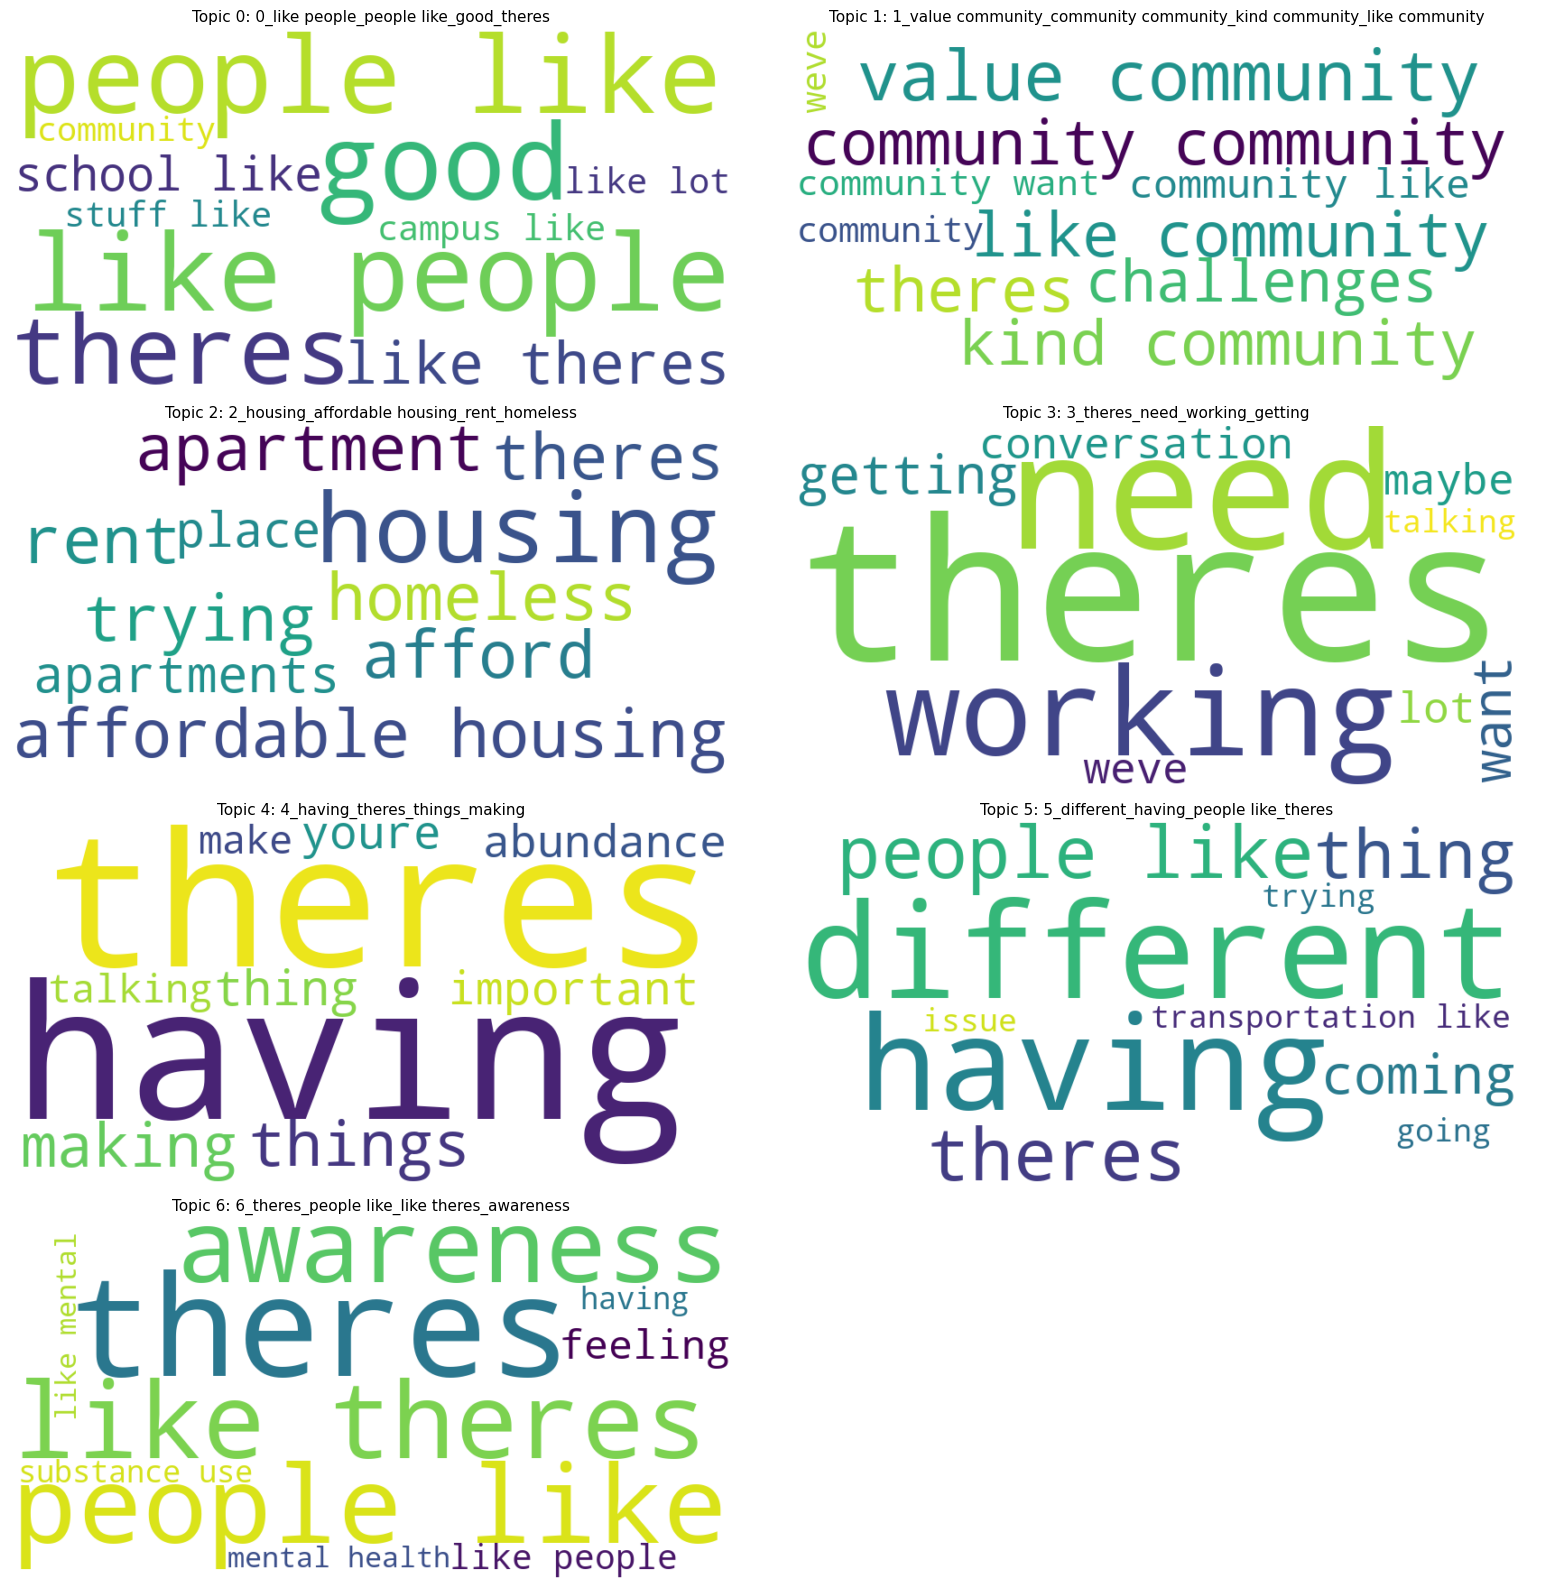

In [187]:
# Show word clouds for all real topics (excluding -1)
real_topics = [t for t in topic_info['Topic'].tolist() if t != -1]

n_topics = len(real_topics)
fig, axes = plt.subplots(
    nrows=(n_topics + 1) // 2, ncols=2,
    figsize=(16, 4 * ((n_topics + 1) // 2))
)
axes = axes.flatten() if n_topics > 1 else [axes]

for i, topic_id in enumerate(real_topics):
    wc = wordcloud_for_topic(topic_model, topic_id)
    if wc is not None:
        axes[i].imshow(wc, interpolation='bilinear')
        topic_label = topic_info.loc[topic_info['Topic'] == topic_id, 'Name'].iloc[0]
        axes[i].set_title(f"Topic {topic_id}: {topic_label}", fontsize=11)
        axes[i].axis('off')

# Hide unused axes
for j in range(len(real_topics), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('topic_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()